In [ ]:
# Customer Churn Prediction using Machine Learning

In [ ]:
## Introduction

Customer churn is a major issue in the telecom industry. This project aims to analyse customer data and predict churn using machine learning techniques to support business decision-making.

In [ ]:
## Business Problem

Telecom companies face high customer churn rates, leading to revenue loss. The objective is to identify customers likely to churn.

## Objectives
- Predict churn
- Identify key factors influencing churn
- Provide business recommendations

In [ ]:
## Dataset Description

The dataset used is the Telco Customer Churn dataset obtained from Kaggle.

It contains information such as:
- Customer demographics
- Service details
- Monthly charges
- Contract type
- Churn status

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For ML
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("C:/Users/User/Downloads/project/telco.csv")

# Check Column Names
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (7043, 21)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [5]:
df = df.dropna()

In [ ]:
## Problem Definition

Customer churn is a critical issue in the telecom industry, leading to revenue loss. This project aims to predict churn and identify key factors influencing customer behaviour.

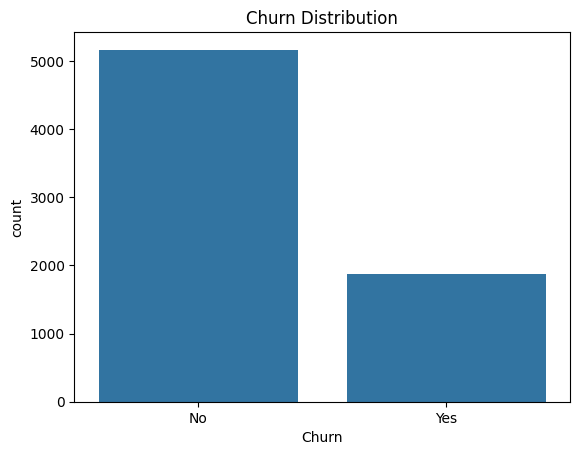

In [6]:
#Exploratory Data Analysis (EDA)

#Churn Distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

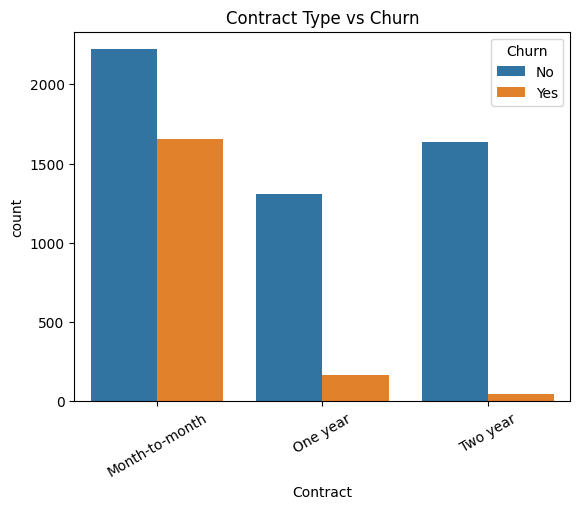

In [7]:
#Contract vs Churn
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=30)
plt.show()

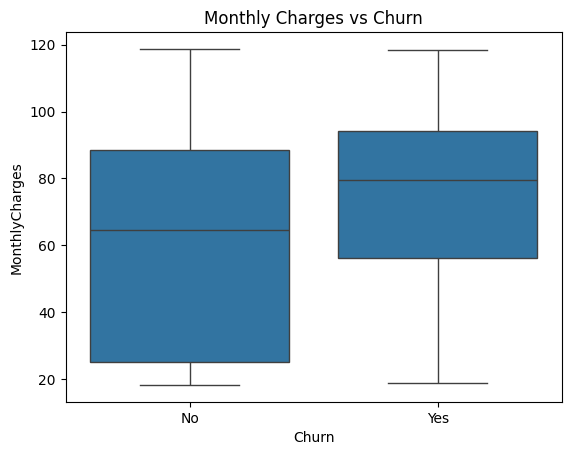

In [8]:
#Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

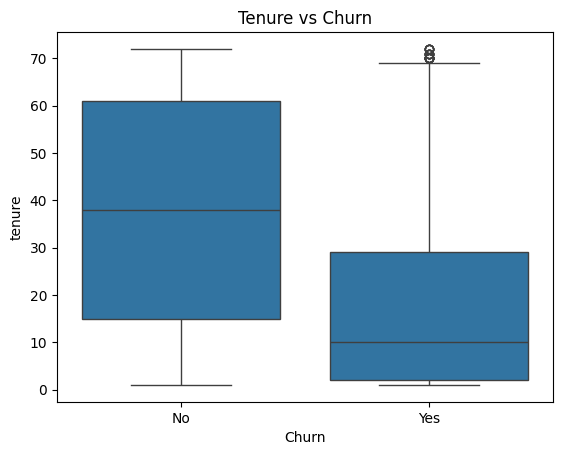

In [9]:
#Tenure vs Churn
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

In [10]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [11]:
X = df.drop('Churn', axis=1)
y = df['Churn']


In [12]:
X = pd.get_dummies(X, drop_first=True)

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
#Logistic Regression

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Create model (only once)
log_model = LogisticRegression(max_iter=2000, solver='liblinear')

# Train model
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))

Accuracy: 0.7839374555792467
Confusion Matrix:
 [[954  79]
 [225 149]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.92      0.86      1033
           1       0.65      0.40      0.50       374

    accuracy                           0.78      1407
   macro avg       0.73      0.66      0.68      1407
weighted avg       0.77      0.78      0.76      1407



In [ ]:
## Methodology

This project follows a structured approach including data cleaning, exploratory data analysis, model building, and evaluation.

In [18]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [19]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.775408670931059

Confusion Matrix:
 [[870 163]
 [153 221]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.59      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.78      0.78      1407



In [20]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Logistic Regression Accuracy: 0.7839374555792467
Decision Tree Accuracy: 0.775408670931059


In [ ]:
## Model Interpretation

The model shows that contract type, monthly charges, and tenure are key factors influencing churn.

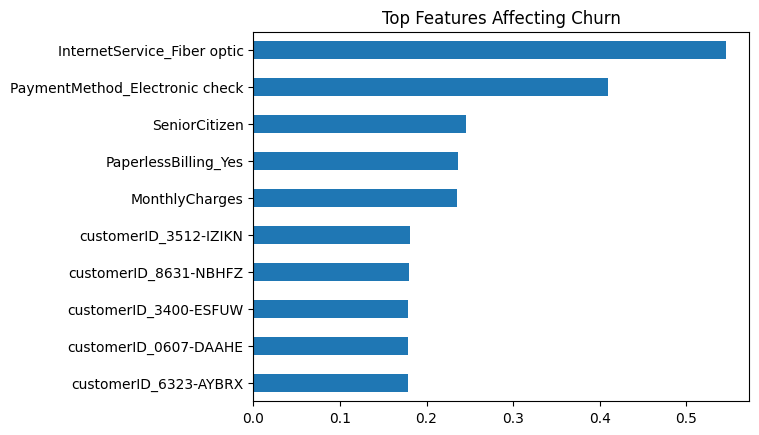

In [21]:
importance = pd.Series(log_model.coef_[0], index=X.columns)
importance.sort_values().tail(10).plot(kind='barh')
plt.title("Top Features Affecting Churn")
plt.show()

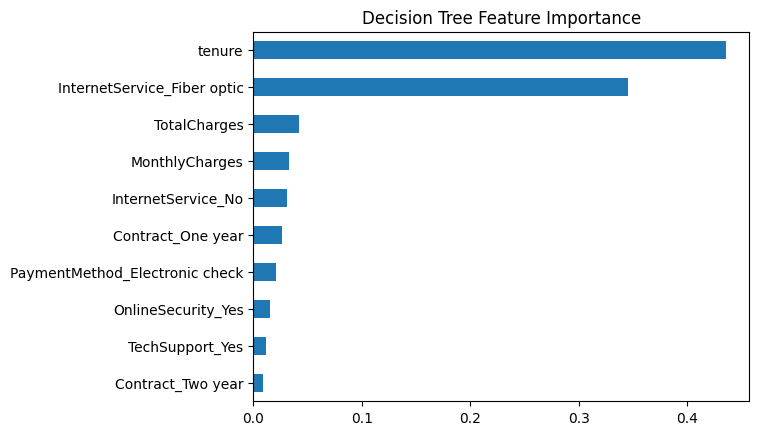

In [22]:
importances = pd.Series(tree_model.feature_importances_, index=X.columns)
importances.sort_values().tail(10).plot(kind='barh')
plt.title("Decision Tree Feature Importance")
plt.show()

In [ ]:
## Business Insights

- Customers with month-to-month contracts are more likely to churn
- High monthly charges increase churn probability
- Customers with longer tenure are less likely to leave

## Recommendations

- Encourage long-term contracts
- Provide discounts to high-risk customers
- Improve customer service for retention

## Ethical, Privacy and Security Considerations

- Bias may exist in model predictions
- Customer data must be handled securely
- Ensure privacy protection and compliance with regulations

## Conclusion

This project successfully applied machine learning to predict customer churn and provided actionable business insights.